In [1]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


import openpyxl


import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv(r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\data\Sales_csv.csv")

In [4]:
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,Order ID,Order Date,Customer ID,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-101343,17-Jul-16,RA-19885,West,OFF-ST-10003479,Office Supplies,Storage,"Eldon Base for stackable storage shelf, platinum",77.88,2,0.0,3.8940
1,CA-2017-163405,21-Dec-17,BN-11515,West,OFF-AR-10003811,Office Supplies,Art,Newell 327,6.63,3,0.0,1.7901
2,CA-2017-163405,21-Dec-17,BN-11515,West,OFF-AR-10001246,Office Supplies,Art,Newell 317,5.88,2,0.0,1.7052
3,US-2016-115819,19-Apr-16,JO-15280,West,OFF-AR-10000823,Office Supplies,Art,Newell 307,5.46,3,0.0,1.5288
4,US-2016-115819,19-Apr-16,JO-15280,West,OFF-AR-10004456,Office Supplies,Art,Panasonic KP-4ABK Battery-Operated Pencil Shar...,73.20,5,0.0,21.2280


In [6]:
df.tail()

,Order ID,Order Date,Customer ID,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,CA-2014-169019,26-Jul-14,LF-17185,Central,OFF-AP-10003281,Office Supplies,Appliances,Acco 6 Outlet Guardian Standard Surge Suppressor,4.836,2,0.8,-12.0900
9990,CA-2014-113257,16-Dec-14,SC-20305,Central,FUR-FU-10001706,Furniture,Furnishings,Longer-Life Soft White Bulbs,8.624,7,0.6,-2.5872
9991,CA-2016-126627,10-Oct-16,WB-21850,Central,FUR-FU-10004963,Furniture,Furnishings,"Eldon 400 Class Desk Accessories, Black Carbon",14.000,4,0.6,-6.3000
9992,CA-2014-122609,12-Nov-14,DP-13000,Central,FUR-FU-10004587,Furniture,Furnishings,"GE General Use Halogen Bulbs, 100 Watts, 1 Bul...",25.128,3,0.6,-6.9102
9993,CA-2016-149272,15-Mar-16,MY-18295,Central,FUR-CH-10000863,Furniture,Chairs,Novimex Swivel Fabric Task Chair,528.430,5,0.3,-143.4310


In [7]:
df.shape

(9994, 12)

In [8]:
df.columns

Index(['Order ID', 'Order Date', 'Customer ID', 'Region', 'Product ID',
       'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity',
       'Discount', 'Profit'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      9994 non-null   object 
 1   Order Date    9994 non-null   object 
 2   Customer ID   9994 non-null   object 
 3   Region        9994 non-null   object 
 4   Product ID    9994 non-null   object 
 5   Category      9994 non-null   object 
 6   Sub-Category  9994 non-null   object 
 7   Product Name  9994 non-null   object 
 8   Sales         9994 non-null   float64
 9   Quantity      9994 non-null   int64  
 10  Discount      9994 non-null   float64
 11  Profit        9994 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 937.1+ KB


In [10]:
df.describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [11]:
df.isnull().sum()

Order ID        0
Order Date      0
Customer ID     0
Region          0
Product ID      0
Category        0
Sub-Category    0
Product Name    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [12]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_percentage.sort_values(
    ascending=False
)

Order ID        0.0
Order Date      0.0
Customer ID     0.0
Region          0.0
Product ID      0.0
Category        0.0
Sub-Category    0.0
Product Name    0.0
Sales           0.0
Quantity        0.0
Discount        0.0
Profit          0.0
dtype: float64

In [13]:
df.duplicated().sum()

np.int64(1)

In [14]:
df[df.duplicated()]

,Order ID,Order Date,Customer ID,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9341,US-2014-150119,23-Apr-14,LB-16795,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


In [15]:
df.dtypes

Order ID         object
Order Date       object
Customer ID      object
Region           object
Product ID       object
Category         object
Sub-Category     object
Product Name     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

In [16]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
)

In [17]:
df['Order Date'].dtype

dtype('<M8[ns]')

In [18]:
df['Order Date'].isnull().sum()

np.int64(0)

In [19]:
df = df.drop_duplicates()

In [20]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [21]:
df = df.rename(columns={
    'Category': 'Product Category',
    'Sales': 'Sales Amount'
})

In [22]:
df.columns

Index(['Order ID', 'Order Date', 'Customer ID', 'Region', 'Product ID',
       'Product Category', 'Sub-Category', 'Product Name', 'Sales Amount',
       'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [23]:
df['Unit Price'] = (
    df['Sales Amount'] / df['Quantity']
)

In [24]:
df[['Sales Amount', 'Quantity', 'Unit Price']].head()

,Sales Amount,Quantity,Unit Price
0,77.88,2,38.94
1,6.63,3,2.21
2,5.88,2,2.94
3,5.46,3,1.82
4,73.20,5,14.64


In [25]:
df['Total Sales'] = df['Sales Amount']

In [26]:
df['Profit Margin'] = (
    df['Profit'] / df['Sales Amount']
) * 100

In [27]:
df[['Sales Amount', 'Profit', 'Profit Margin']].head()

,Sales Amount,Profit,Profit Margin
0,77.88,3.8940,5.0
1,6.63,1.7901,27.0
2,5.88,1.7052,29.0
3,5.46,1.5288,28.0
4,73.20,21.2280,29.0


In [28]:
df['Month'] = df['Order Date'].dt.month_name()

In [29]:
df[['Order Date', 'Month']].head()

,Order Date,Month
0,2016-07-17,July
1,2017-12-21,December
2,2017-12-21,December
3,2016-04-19,April
4,2016-04-19,April


In [30]:
df['Quarter'] = (
    df['Order Date']
    .dt.to_period('Q')
    .astype(str)
)

In [31]:
df[['Order Date', 'Quarter']].head()

,Order Date,Quarter
0,2016-07-17,2016Q3
1,2017-12-21,2017Q4
2,2017-12-21,2017Q4
3,2016-04-19,2016Q2
4,2016-04-19,2016Q2


In [32]:
df['Year'] = df['Order Date'].dt.year

In [33]:
df[['Order Date', 'Year']].head()

,Order Date,Year
0,2016-07-17,2016
1,2017-12-21,2017
2,2017-12-21,2017
3,2016-04-19,2016
4,2016-04-19,2016


In [34]:
df.head()

,Order ID,Order Date,Customer ID,Region,Product ID,Product Category,Sub-Category,Product Name,Sales Amount,Quantity,Discount,Profit,Unit Price,Total Sales,Profit Margin,Month,Quarter,Year
0,CA-2016-101343,2016-07-17,RA-19885,West,OFF-ST-10003479,Office Supplies,Storage,"Eldon Base for stackable storage shelf, platinum",77.88,2,0.0,3.8940,38.94,77.88,5.0,July,2016Q3,2016
1,CA-2017-163405,2017-12-21,BN-11515,West,OFF-AR-10003811,Office Supplies,Art,Newell 327,6.63,3,0.0,1.7901,2.21,6.63,27.0,December,2017Q4,2017
2,CA-2017-163405,2017-12-21,BN-11515,West,OFF-AR-10001246,Office Supplies,Art,Newell 317,5.88,2,0.0,1.7052,2.94,5.88,29.0,December,2017Q4,2017
3,US-2016-115819,2016-04-19,JO-15280,West,OFF-AR-10000823,Office Supplies,Art,Newell 307,5.46,3,0.0,1.5288,1.82,5.46,28.0,April,2016Q2,2016
4,US-2016-115819,2016-04-19,JO-15280,West,OFF-AR-10004456,Office Supplies,Art,Panasonic KP-4ABK Battery-Operated Pencil Shar...,73.20,5,0.0,21.2280,14.64,73.20,29.0,April,2016Q2,2016


In [35]:
df.shape

(9993, 18)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order ID          9993 non-null   object        
 1   Order Date        9993 non-null   datetime64[ns]
 2   Customer ID       9993 non-null   object        
 3   Region            9993 non-null   object        
 4   Product ID        9993 non-null   object        
 5   Product Category  9993 non-null   object        
 6   Sub-Category      9993 non-null   object        
 7   Product Name      9993 non-null   object        
 8   Sales Amount      9993 non-null   float64       
 9   Quantity          9993 non-null   int64         
 10  Discount          9993 non-null   float64       
 11  Profit            9993 non-null   float64       
 12  Unit Price        9993 non-null   float64       
 13  Total Sales       9993 non-null   float64       
 14  Profit Margin     9993 non-nu

In [37]:
df.isnull().sum()

Order ID            0
Order Date          0
Customer ID         0
Region              0
Product ID          0
Product Category    0
Sub-Category        0
Product Name        0
Sales Amount        0
Quantity            0
Discount            0
Profit              0
Unit Price          0
Total Sales         0
Profit Margin       0
Month               0
Quarter             0
Year                0
dtype: int64

In [40]:
df.to_csv(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\data\retail_sales_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [41]:
total_sales = df['Total Sales'].sum()

print("Total Sales:", round(total_sales, 2))

Total Sales: 2296919.49


In [42]:
total_orders = df['Order ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 5009


In [43]:
total_customers = df['Customer ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 793


In [44]:
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 37871


In [45]:
total_profit = df['Profit'].sum()

print("Total Profit:", round(total_profit, 2))

Total Profit: 286409.08


In [46]:
overall_profit_margin = (
    total_profit / total_sales
) * 100

print(
    "Overall Profit Margin:",
    round(overall_profit_margin, 2),
    "%"
)

Overall Profit Margin: 12.47 %


In [47]:
average_order_value = (
    total_sales / total_orders
)

print(
    "Average Order Value:",
    round(average_order_value, 2)
)

Average Order Value: 458.56


In [48]:
top_10_products = (
    df.groupby('Product Name')['Total Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Total Sales, dtype: float64

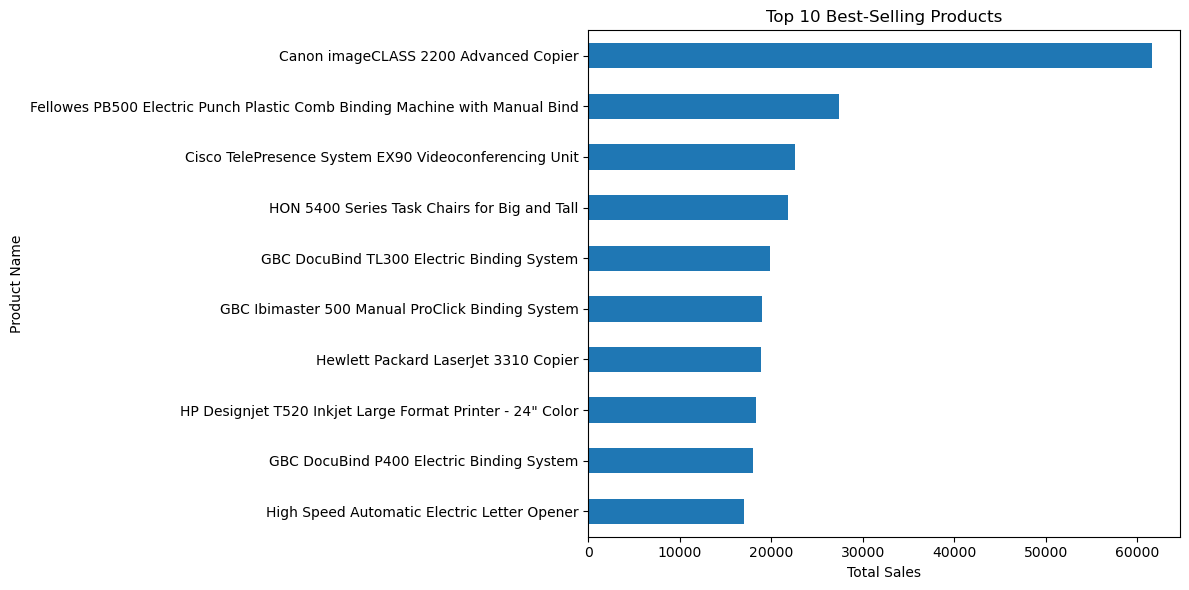

In [49]:
plt.figure(figsize=(12, 6))

top_10_products.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')

plt.tight_layout()

plt.savefig(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\charts\top_10_products.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [50]:
top_5_categories = (
    df.groupby('Product Category')['Total Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_5_categories

Product Category
Technology         836154.0330
Furniture          741718.4233
Office Supplies    719047.0320
Name: Total Sales, dtype: float64

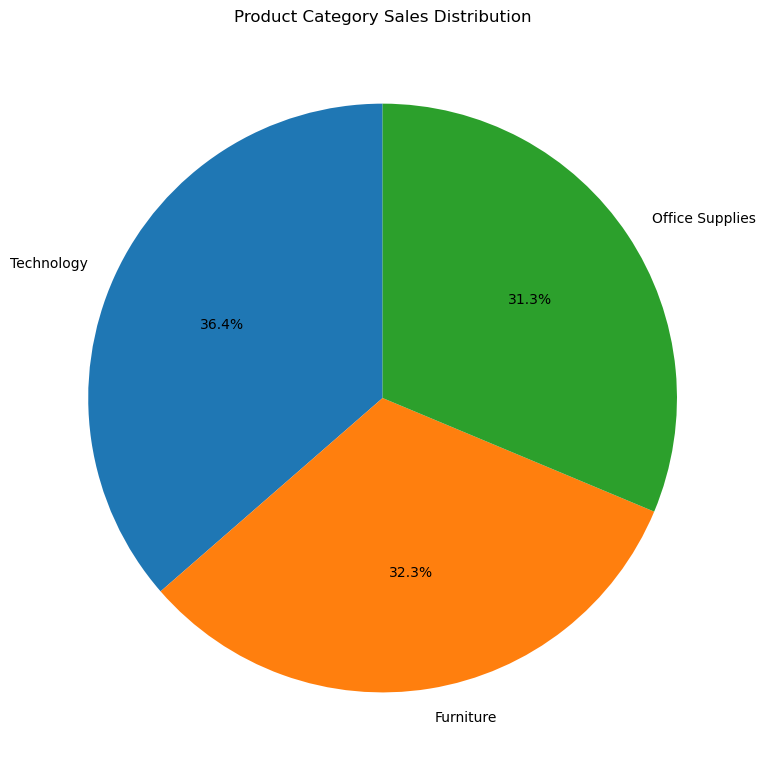

In [51]:
category_sales = (
    df.groupby('Product Category')['Total Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 8))

plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Product Category Sales Distribution')

plt.tight_layout()

plt.savefig(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\charts\category_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [52]:
region_sales = (
    df.groupby('Region')['Total Sales']
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
West       725457.8245
East       678499.8680
Central    501239.8908
South      391721.9050
Name: Total Sales, dtype: float64

In [53]:
highest_performing_region = region_sales.idxmax()

print(
    "Highest Performing Region:",
    highest_performing_region
)

Highest Performing Region: West


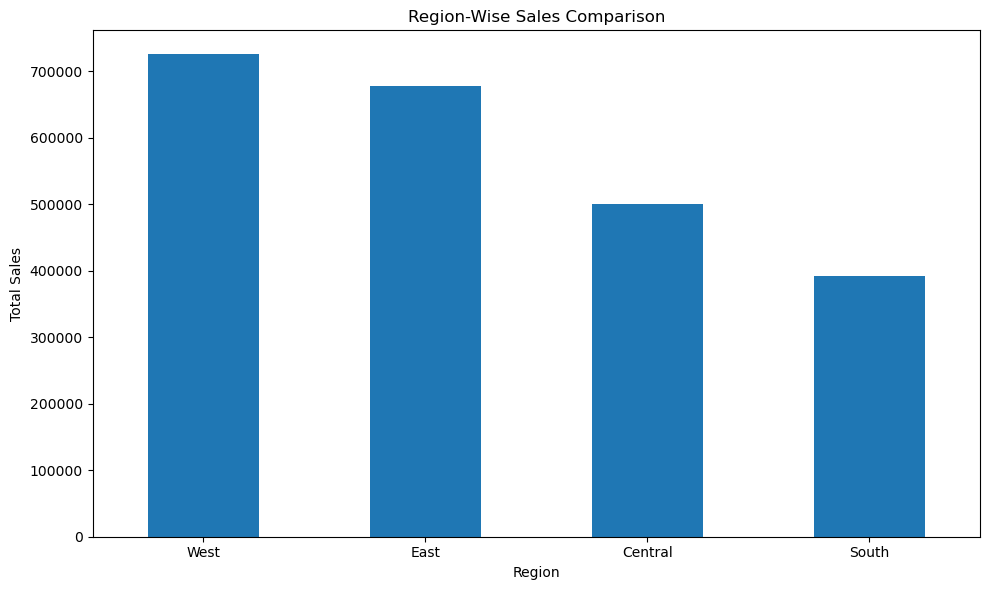

In [54]:
plt.figure(figsize=(10, 6))

region_sales.plot(
    kind='bar'
)

plt.title('Region-Wise Sales Comparison')
plt.xlabel('Region')
plt.ylabel('Total Sales')

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\charts\region_sales_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [55]:
monthly_sales = (
    df.groupby(
        ['Year', 'Month']
    )['Total Sales']
    .sum()
    .reset_index()
)

monthly_sales

,Year,Month,Total Sales
0,2014,April,28013.9730
1,2014,August,27909.4685
2,2014,December,69545.6205
3,2014,February,4519.8920
4,2014,January,14236.8950
5,2014,July,33946.3930
6,2014,June,34595.1276
7,2014,March,55691.0090
8,2014,May,23648.2870
9,2014,November,78628.7167


In [56]:
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

In [57]:
monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories=month_order,
    ordered=True
)

In [58]:
monthly_sales = monthly_sales.sort_values(
    ['Year', 'Month']
)

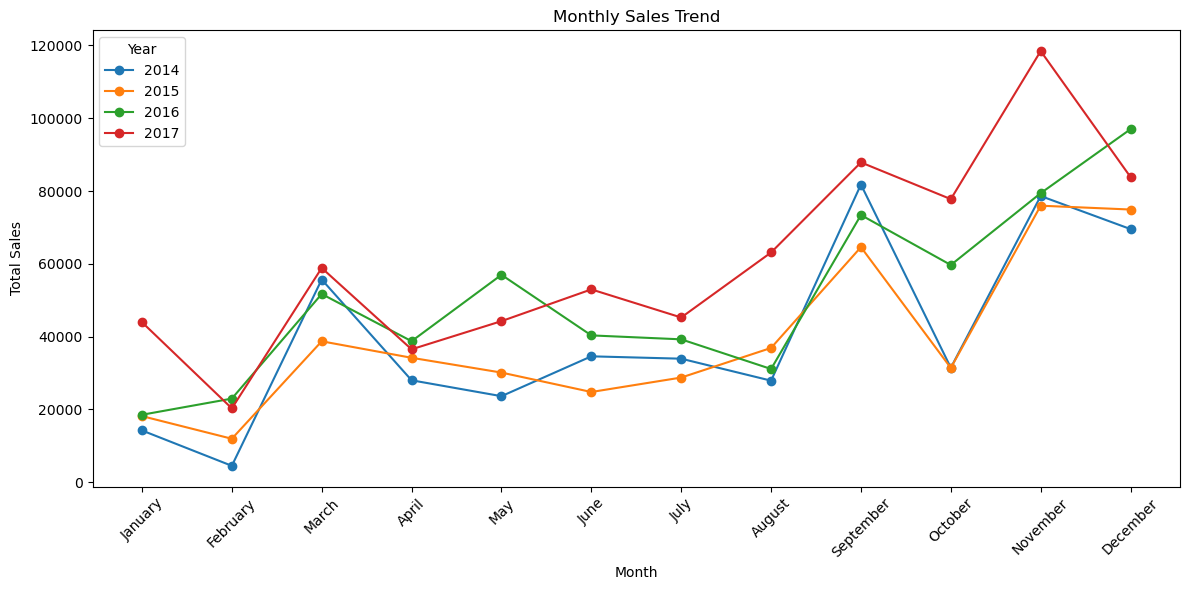

In [59]:
plt.figure(figsize=(12, 6))

for year in monthly_sales['Year'].unique():

    yearly_data = monthly_sales[
        monthly_sales['Year'] == year
    ]

    plt.plot(
        yearly_data['Month'].astype(str),
        yearly_data['Total Sales'],
        marker='o',
        label=str(year)
    )

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.legend(title='Year')

plt.tight_layout()

plt.savefig(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\charts\monthly_sales_trend.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [60]:
customer_frequency = (
    df.groupby('Customer ID')['Order ID']
    .nunique()
    .sort_values(ascending=False)
)

customer_frequency.head(10)

Customer ID
EP-13915    17
ZC-21910    13
CK-12205    13
SH-19975    13
JE-15745    13
EA-14035    13
PG-18820    13
NS-18640    13
SJ-20125    12
EH-13765    12
Name: Order ID, dtype: int64

In [61]:
orders_per_customer = (
    df.groupby('Customer ID')['Order ID']
    .nunique()
)

In [62]:
repeat_customers = (
    orders_per_customer > 1
).sum()

In [63]:
total_customers = (
    orders_per_customer.count()
)

In [64]:
repeat_customer_percentage = (
    repeat_customers / total_customers
) * 100

print(
    "Repeat Customer Percentage:",
    round(repeat_customer_percentage, 2),
    "%"
)

Repeat Customer Percentage: 98.49 %


In [65]:
customer_purchase_value = (
    df.groupby('Customer ID')['Total Sales']
    .sum()
    .sort_values(ascending=False)
)

customer_purchase_value.head(10)

Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: Total Sales, dtype: float64

In [66]:
customer_aov = (
    df.groupby('Customer ID')
    .agg(
        Total_Purchase_Value=('Total Sales', 'sum'),
        Purchase_Frequency=('Order ID', 'nunique')
    )
)

customer_aov['Average_Order_Value'] = (
    customer_aov['Total_Purchase_Value']
    /
    customer_aov['Purchase_Frequency']
)

customer_aov.head()

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value
Customer ID,,,
AA-10315,5563.560,5,1112.712000
AA-10375,1056.390,9,117.376667
AA-10480,1790.512,4,447.628000
AA-10645,5086.935,6,847.822500
AB-10015,886.156,3,295.385333


In [67]:
customer_aov.head(10)

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value
Customer ID,,,
AA-10315,5563.560,5,1112.712000
AA-10375,1056.390,9,117.376667
AA-10480,1790.512,4,447.628000
AA-10645,5086.935,6,847.822500
AB-10015,886.156,3,295.385333
AB-10060,7755.620,8,969.452500
AB-10105,14473.571,10,1447.357100
AB-10150,966.710,5,193.342000
AB-10165,1113.838,8,139.229750


In [68]:
customer_aov.shape

(793, 3)

In [69]:
customer_aov.describe()

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value
count,793.000000,793.000000,793.000000
mean,2896.493680,6.316520,460.103382
std,2628.406787,2.550885,433.386042
min,4.833000,1.000000,2.416500
25%,1146.050000,5.000000,213.255333
50%,2256.394000,6.000000,362.503250
75%,3785.276000,8.000000,550.377000
max,25043.050000,17.000000,5008.610000


In [70]:
customer_features = customer_aov[
    [
        'Total_Purchase_Value',
        'Purchase_Frequency',
        'Average_Order_Value'
    ]
].copy()

In [71]:
customer_features.head()

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value
Customer ID,,,
AA-10315,5563.560,5,1112.712000
AA-10375,1056.390,9,117.376667
AA-10480,1790.512,4,447.628000
AA-10645,5086.935,6,847.822500
AB-10015,886.156,3,295.385333


In [72]:
scaler = StandardScaler()

customer_features_scaled = scaler.fit_transform(
    customer_features
)

In [73]:
customer_features_scaled = pd.DataFrame(
    customer_features_scaled,
    columns=customer_features.columns,
    index=customer_features.index
)

In [74]:
customer_features_scaled.head()

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value
Customer ID,,,
AA-10315,1.015349,-0.516429,1.506787
AA-10375,-0.700525,1.052644,-0.791311
AA-10480,-0.421046,-0.908697,-0.028804
AA-10645,0.833898,-0.124161,0.895192
AB-10015,-0.765333,-1.300965,-0.380312


In [75]:
inertia = []

for k in range(2, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(customer_features_scaled)
    
    inertia.append(kmeans.inertia_)

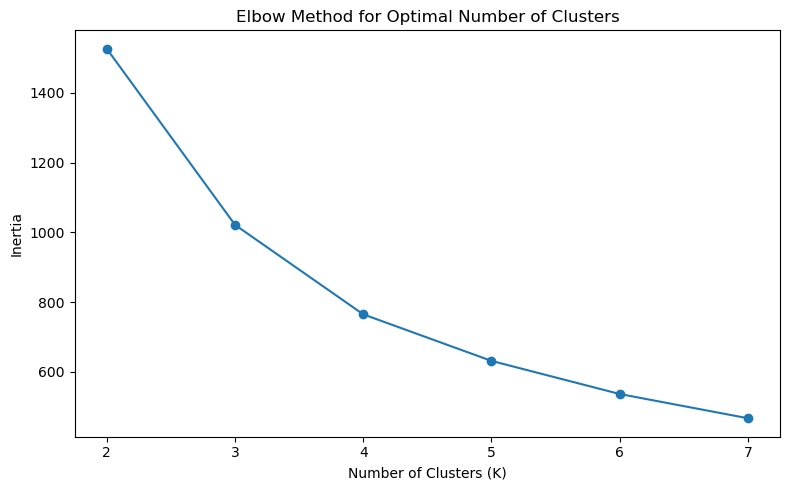

In [76]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 8),
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.tight_layout()

plt.show()

In [77]:
n_clusters=3

In [78]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_aov['Cluster'] = kmeans.fit_predict(
    customer_features_scaled
)

In [79]:
customer_aov.head()

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value,Cluster
Customer ID,,,,
AA-10315,5563.560,5,1112.712000,1
AA-10375,1056.390,9,117.376667,2
AA-10480,1790.512,4,447.628000,0
AA-10645,5086.935,6,847.822500,2
AB-10015,886.156,3,295.385333,0


In [80]:
cluster_summary = (
    customer_aov
    .groupby('Cluster')
    [
        [
            'Total_Purchase_Value',
            'Purchase_Frequency',
            'Average_Order_Value'
        ]
    ]
    .mean()
    .round(2)
)

cluster_summary

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value
Cluster,,,
0,1516.53,4.55,343.02
1,9780.10,6.90,1586.85
2,3646.67,8.65,433.30


In [81]:
cluster_labels = {
    0: 'Occasional',
    1: 'Regular',
    2: 'High Value'
}

customer_aov['Customer Segment'] = (
    customer_aov['Cluster']
    .map(cluster_labels)
)

In [82]:
customer_aov.head()

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value,Cluster,Customer Segment
Customer ID,,,,,
AA-10315,5563.560,5,1112.712000,1,Regular
AA-10375,1056.390,9,117.376667,2,High Value
AA-10480,1790.512,4,447.628000,0,Occasional
AA-10645,5086.935,6,847.822500,2,High Value
AB-10015,886.156,3,295.385333,0,Occasional


In [83]:
cluster_summary

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value
Cluster,,,
0,1516.53,4.55,343.02
1,9780.10,6.90,1586.85
2,3646.67,8.65,433.30


In [84]:
cluster_labels = {
    0: 'Occasional',
    1: 'High Value',
    2: 'Regular'
}

customer_aov['Customer Segment'] = (
    customer_aov['Cluster']
    .map(cluster_labels)
)

In [85]:
customer_aov.head(10)

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value,Cluster,Customer Segment
Customer ID,,,,,
AA-10315,5563.560,5,1112.712000,1,High Value
AA-10375,1056.390,9,117.376667,2,Regular
AA-10480,1790.512,4,447.628000,0,Occasional
AA-10645,5086.935,6,847.822500,2,Regular
AB-10015,886.156,3,295.385333,0,Occasional
AB-10060,7755.620,8,969.452500,1,High Value
AB-10105,14473.571,10,1447.357100,1,High Value
AB-10150,966.710,5,193.342000,0,Occasional
AB-10165,1113.838,8,139.229750,2,Regular


In [86]:
segment_counts = (
    customer_aov['Customer Segment']
    .value_counts()
)

segment_counts

Customer Segment
Occasional    429
Regular       312
High Value     52
Name: count, dtype: int64

In [87]:
segment_percentage = (
    customer_aov['Customer Segment']
    .value_counts(normalize=True) * 100
).round(2)

segment_percentage

Customer Segment
Occasional    54.10
Regular       39.34
High Value     6.56
Name: proportion, dtype: float64

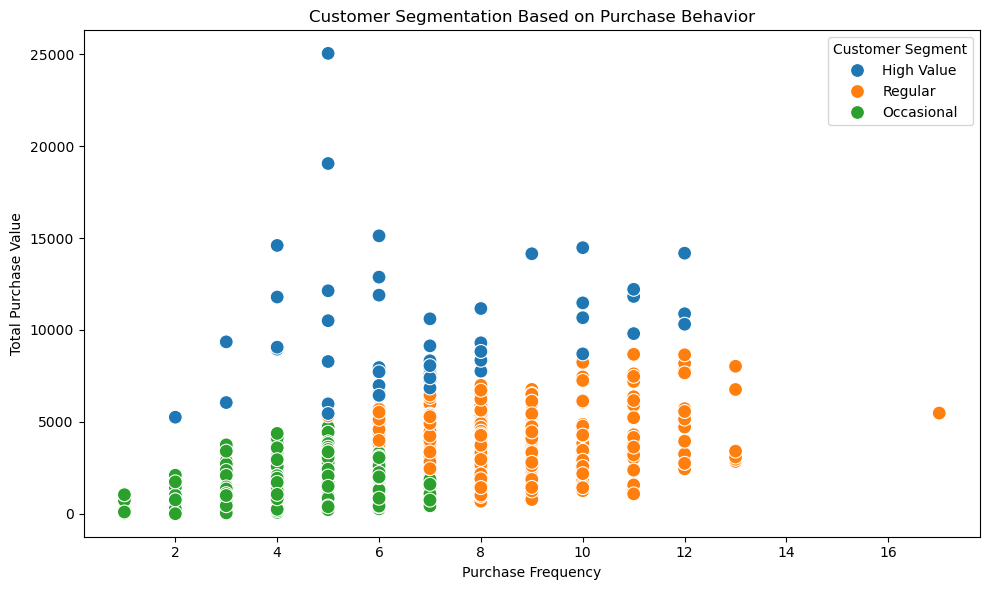

In [88]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_aov,
    x='Purchase_Frequency',
    y='Total_Purchase_Value',
    hue='Customer Segment',
    s=100
)

plt.title('Customer Segmentation Based on Purchase Behavior')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Purchase Value')

plt.legend(title='Customer Segment')

plt.tight_layout()

plt.savefig(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\charts\customer_segmentation.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [89]:
segment_summary = (
    customer_aov
    .groupby('Customer Segment')
    .agg(
        Number_of_Customers=('Customer Segment', 'count'),
        Avg_Total_Purchase_Value=('Total_Purchase_Value', 'mean'),
        Avg_Purchase_Frequency=('Purchase_Frequency', 'mean'),
        Avg_Order_Value=('Average_Order_Value', 'mean')
    )
    .round(2)
)

segment_summary

,Number_of_Customers,Avg_Total_Purchase_Value,Avg_Purchase_Frequency,Avg_Order_Value
Customer Segment,,,,
High Value,52,9780.10,6.90,1586.85
Occasional,429,1516.53,4.55,343.02
Regular,312,3646.67,8.65,433.30


In [90]:
segment_summary = segment_summary.sort_values(
    'Avg_Total_Purchase_Value',
    ascending=False
)

segment_summary

,Number_of_Customers,Avg_Total_Purchase_Value,Avg_Purchase_Frequency,Avg_Order_Value
Customer Segment,,,,
High Value,52,9780.10,6.90,1586.85
Regular,312,3646.67,8.65,433.30
Occasional,429,1516.53,4.55,343.02


In [91]:
customer_aov

,Total_Purchase_Value,Purchase_Frequency,Average_Order_Value,Cluster,Customer Segment
Customer ID,,,,,
AA-10315,5563.560,5,1112.712000,1,High Value
AA-10375,1056.390,9,117.376667,2,Regular
AA-10480,1790.512,4,447.628000,0,Occasional
AA-10645,5086.935,6,847.822500,2,Regular
AB-10015,886.156,3,295.385333,0,Occasional
...,...,...,...,...,...
XP-21865,2374.658,11,215.878000,2,Regular
YC-21895,5454.350,5,1090.870000,1,High Value
YS-21880,6720.444,8,840.055500,2,Regular


In [92]:
df

,Order ID,Order Date,Customer ID,Region,Product ID,Product Category,Sub-Category,Product Name,Sales Amount,Quantity,Discount,Profit,Unit Price,Total Sales,Profit Margin,Month,Quarter,Year
0,CA-2016-101343,2016-07-17,RA-19885,West,OFF-ST-10003479,Office Supplies,Storage,"Eldon Base for stackable storage shelf, platinum",77.880,2,0.0,3.8940,38.940,77.880,5.000000,July,2016Q3,2016
1,CA-2017-163405,2017-12-21,BN-11515,West,OFF-AR-10003811,Office Supplies,Art,Newell 327,6.630,3,0.0,1.7901,2.210,6.630,27.000000,December,2017Q4,2017
2,CA-2017-163405,2017-12-21,BN-11515,West,OFF-AR-10001246,Office Supplies,Art,Newell 317,5.880,2,0.0,1.7052,2.940,5.880,29.000000,December,2017Q4,2017
3,US-2016-115819,2016-04-19,JO-15280,West,OFF-AR-10000823,Office Supplies,Art,Newell 307,5.460,3,0.0,1.5288,1.820,5.460,28.000000,April,2016Q2,2016
4,US-2016-115819,2016-04-19,JO-15280,West,OFF-AR-10004456,Office Supplies,Art,Panasonic KP-4ABK Battery-Operated Pencil Shar...,73.200,5,0.0,21.2280,14.640,73.200,29.000000,April,2016Q2,2016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,CA-2014-169019,2014-07-26,LF-17185,Central,OFF-AP-10003281,Office Supplies,Appliances,Acco 6 Outlet Guardian Standard Surge Suppressor,4.836,2,0.8,-12.0900,2.418,4.836,-250.000000,July,2014Q3,2014
9990,CA-2014-113257,2014-12-16,SC-20305,Central,FUR-FU-10001706,Furniture,Furnishings,Longer-Life Soft White Bulbs,8.624,7,0.6,-2.5872,1.232,8.624,-30.000000,December,2014Q4,2014
9991,CA-2016-126627,2016-10-10,WB-21850,Central,FUR-FU-10004963,Furniture,Furnishings,"Eldon 400 Class Desk Accessories, Black Carbon",14.000,4,0.6,-6.3000,3.500,14.000,-45.000000,October,2016Q4,2016
9992,CA-2014-122609,2014-11-12,DP-13000,Central,FUR-FU-10004587,Furniture,Furnishings,"GE General Use Halogen Bulbs, 100 Watts, 1 Bul...",25.128,3,0.6,-6.9102,8.376,25.128,-27.500000,November,2014Q4,2014


In [93]:
df = df.merge(
    customer_aov[['Customer Segment']],
    left_on='Customer ID',
    right_index=True,
    how='left'
)

In [94]:
df[['Customer ID', 'Customer Segment']].head(10)

,Customer ID,Customer Segment
0,RA-19885,Regular
1,BN-11515,Occasional
2,BN-11515,Occasional
3,JO-15280,Occasional
4,JO-15280,Occasional
5,JO-15280,Occasional
6,GK-14620,Regular
7,GG-14650,Regular
8,GG-14650,Regular
9,GG-14650,Regular


In [95]:
df.to_csv(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\data\retail_sales_cleaned.csv",
    index=False
)

print("Final processed dataset saved successfully!")

Final processed dataset saved successfully!


In [96]:
category_performance = (
    df.groupby('Product Category')
    .agg(
        Total_Sales=('Total Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Average_Profit_Margin=('Profit Margin', 'mean')
    )
    .sort_values(
        'Total_Sales',
        ascending=False
    )
)

category_performance.round(2)

,Total_Sales,Total_Profit,Total_Quantity,Average_Profit_Margin
Product Category,,,,
Technology,836154.03,145454.95,6939,15.61
Furniture,741718.42,18463.33,8026,3.88
Office Supplies,719047.03,122490.80,22906,13.80


In [97]:
best_selling_category = category_performance.index[0]

print(
    "Best-Selling Product Category:",
    best_selling_category
)

Best-Selling Product Category: Technology


In [98]:
most_profitable_category = (
    category_performance['Total_Profit']
    .idxmax()
)

print(
    "Most Profitable Category:",
    most_profitable_category
)

Most Profitable Category: Technology


In [99]:
low_performing_products = (
    df.groupby('Product Name')
    .agg(
        Total_Sales=('Total Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Quantity_Sold=('Quantity', 'sum')
    )
    .sort_values(
        'Total_Sales',
        ascending=True
    )
    .head(10)
)

low_performing_products

,Total_Sales,Total_Profit,Quantity_Sold
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624,-4.4660,2
Avery 5,5.760,2.8224,2
Xerox 20,6.480,3.1104,1
Grip Seal Envelopes,7.072,2.3868,2
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700,3.1570,2
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800,3.0420,4
Xerox 1989,7.968,2.6892,2
4009 Highlighters,8.040,2.7336,6
Stockwell Gold Paper Clips,8.096,3.4040,5


In [100]:
region_performance = (
    df.groupby('Region')
    .agg(
        Total_Sales=('Total Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Total_Quantity=('Quantity', 'sum')
    )
    .sort_values(
        'Total_Sales',
        ascending=False
    )
)

region_performance.round(2)

,Total_Sales,Total_Profit,Total_Quantity
Region,,,
West,725457.82,108418.45,12266
East,678499.87,91534.84,10616
Central,501239.89,39706.36,8780
South,391721.90,46749.43,6209


In [101]:
best_region = region_performance.index[0]

print(
    "Highest Performing Region:",
    best_region
)

Highest Performing Region: West


In [102]:
monthly_performance = (
    df.groupby('Month')
    .agg(
        Total_Sales=('Total Sales', 'sum'),
        Total_Profit=('Profit', 'sum')
    )
)

monthly_performance['Month_Order'] = (
    monthly_performance.index.map(
        {month: i for i, month in enumerate(month_order)}
    )
)

monthly_performance = (
    monthly_performance
    .sort_values('Month_Order')
)

monthly_performance

,Total_Sales,Total_Profit,Month_Order
Month,,,
January,94924.8356,9134.4461,0
February,59751.2514,10294.6107,1
March,205005.4888,28594.6872,2
April,137480.7566,11599.4951,3
May,155028.8117,22411.3078,4
June,152718.6793,21285.7954,5
July,147238.0970,13832.6648,6
August,159044.0630,21776.9384,7
September,307649.9457,36857.4753,8


In [103]:
best_month = (
    monthly_performance['Total_Sales']
    .idxmax()
)

print("Best Sales Month:", best_month)

Best Sales Month: November


In [104]:
lowest_month = (
    monthly_performance['Total_Sales']
    .idxmin()
)

print("Lowest Sales Month:", lowest_month)

Lowest Sales Month: February


In [105]:
segment_summary

,Number_of_Customers,Avg_Total_Purchase_Value,Avg_Purchase_Frequency,Avg_Order_Value
Customer Segment,,,,
High Value,52,9780.10,6.90,1586.85
Regular,312,3646.67,8.65,433.30
Occasional,429,1516.53,4.55,343.02


In [106]:
most_valuable_segment = (
    segment_summary[
        'Avg_Total_Purchase_Value'
    ].idxmax()
)

print(
    "Most Valuable Customer Segment:",
    most_valuable_segment
)

Most Valuable Customer Segment: High Value


In [107]:
largest_customer_segment = (
    segment_summary[
        'Number_of_Customers'
    ].idxmax()
)

print(
    "Largest Customer Segment:",
    largest_customer_segment
)

Largest Customer Segment: Occasional


In [108]:
discount_profit = (
    df.groupby('Discount')
    .agg(
        Total_Sales=('Total Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Average_Profit_Margin=('Profit Margin', 'mean')
    )
    .sort_index()
)

discount_profit.round(2)

,Total_Sales,Total_Profit,Average_Profit_Margin
Discount,,,
0.00,1087908.47,320987.60,34.02
0.10,54369.35,9029.18,15.58
0.15,27558.52,1418.99,3.42
0.20,764594.37,90337.31,17.68
0.30,102945.28,-10357.22,-11.58
0.32,14493.46,-2391.14,-17.43
0.40,116417.78,-23057.05,-22.25
0.45,5484.97,-2493.11,-45.45
0.50,58918.54,-20506.43,-54.91


In [109]:
product_performance = (
    df.groupby('Product Name')
    .agg(
        Total_Sales=('Total Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Quantity_Sold=('Quantity', 'sum')
    )
)

In [110]:
high_sales_products = (
    product_performance
    .sort_values(
        'Total_Sales',
        ascending=False
    )
    .head(20)
)

high_sales_products

,Total_Sales,Total_Profit,Quantity_Sold
Product Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.8240,2.519993e+04,20
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.3840,7.753039e+03,31
Cisco TelePresence System EX90 Videoconferencing Unit,22638.4800,-1.811078e+03,6
HON 5400 Series Task Chairs for Big and Tall,21870.5760,1.421085e-13,39
GBC DocuBind TL300 Electric Binding System,19823.4790,2.233505e+03,37
GBC Ibimaster 500 Manual ProClick Binding System,19024.5000,7.609800e+02,48
Hewlett Packard LaserJet 3310 Copier,18839.6860,6.983884e+03,38
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.8950,4.094977e+03,12
GBC DocuBind P400 Electric Binding System,17965.0680,-1.878166e+03,27


In [111]:
kpi_summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Total Orders',
        'Total Customers',
        'Total Quantity Sold',
        'Average Order Value',
        'Overall Profit Margin',
        'Repeat Customer Percentage',
        'Highest Performing Region',
        'Best-Selling Category',
        'Most Valuable Customer Segment'
    ],
    
    'Value': [
        round(total_sales, 2),
        round(total_profit, 2),
        total_orders,
        total_customers,
        total_quantity,
        round(average_order_value, 2),
        round(overall_profit_margin, 2),
        round(repeat_customer_percentage, 2),
        best_region,
        best_selling_category,
        most_valuable_segment
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,2296919.49
1,Total Profit,286409.08
2,Total Orders,5009
3,Total Customers,793
4,Total Quantity Sold,37871
5,Average Order Value,458.56
6,Overall Profit Margin,12.47
7,Repeat Customer Percentage,98.49
8,Highest Performing Region,West
9,Best-Selling Category,Technology


In [117]:
##  Business Insights

In [116]:
kpi_summary

,Metric,Value
0,Total Sales,2296919.49
1,Total Profit,286409.08
2,Total Orders,5009
3,Total Customers,793
4,Total Quantity Sold,37871
5,Average Order Value,458.56
6,Overall Profit Margin,12.47
7,Repeat Customer Percentage,98.49
8,Highest Performing Region,West
9,Best-Selling Category,Technology


In [113]:
category_performance

,Total_Sales,Total_Profit,Total_Quantity,Average_Profit_Margin
Product Category,,,,
Technology,836154.0330,145454.9481,6939,15.613805
Furniture,741718.4233,18463.3316,8026,3.882204
Office Supplies,719047.0320,122490.8008,22906,13.803029


In [114]:
region_performance

,Total_Sales,Total_Profit,Total_Quantity
Region,,,
West,725457.8245,108418.4489,12266
East,678499.8680,91534.8388,10616
Central,501239.8908,39706.3625,8780
South,391721.9050,46749.4303,6209


In [115]:
segment_summary

,Number_of_Customers,Avg_Total_Purchase_Value,Avg_Purchase_Frequency,Avg_Order_Value
Customer Segment,,,,
High Value,52,9780.10,6.90,1586.85
Regular,312,3646.67,8.65,433.30
Occasional,429,1516.53,4.55,343.02


In [118]:
## Customer Retention Analysis

In [119]:
orders_per_customer = (
    df.groupby('Customer ID')['Order ID']
    .nunique()
)

orders_per_customer.describe()

count    793.000000
mean       6.316520
std        2.550885
min        1.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       17.000000
Name: Order ID, dtype: float64

In [120]:
one_time_customers = (
    (orders_per_customer == 1).sum()
)

print("One-Time Customers:", one_time_customers)

One-Time Customers: 12


In [121]:
repeat_customers = (
    (orders_per_customer > 1).sum()
)

print("Repeat Customers:", repeat_customers)

Repeat Customers: 781


In [122]:
total_customers = orders_per_customer.count()

print("Total Customers:", total_customers)

Total Customers: 793


In [123]:
repeat_customer_percentage = (
    repeat_customers / total_customers
) * 100

print(
    "Repeat Customer Percentage:",
    round(repeat_customer_percentage, 2),
    "%"
)

Repeat Customer Percentage: 98.49 %


In [124]:
##  Seasonal Sales Analysis

In [125]:
monthly_performance

,Total_Sales,Total_Profit,Month_Order
Month,,,
January,94924.8356,9134.4461,0
February,59751.2514,10294.6107,1
March,205005.4888,28594.6872,2
April,137480.7566,11599.4951,3
May,155028.8117,22411.3078,4
June,152718.6793,21285.7954,5
July,147238.0970,13832.6648,6
August,159044.0630,21776.9384,7
September,307649.9457,36857.4753,8


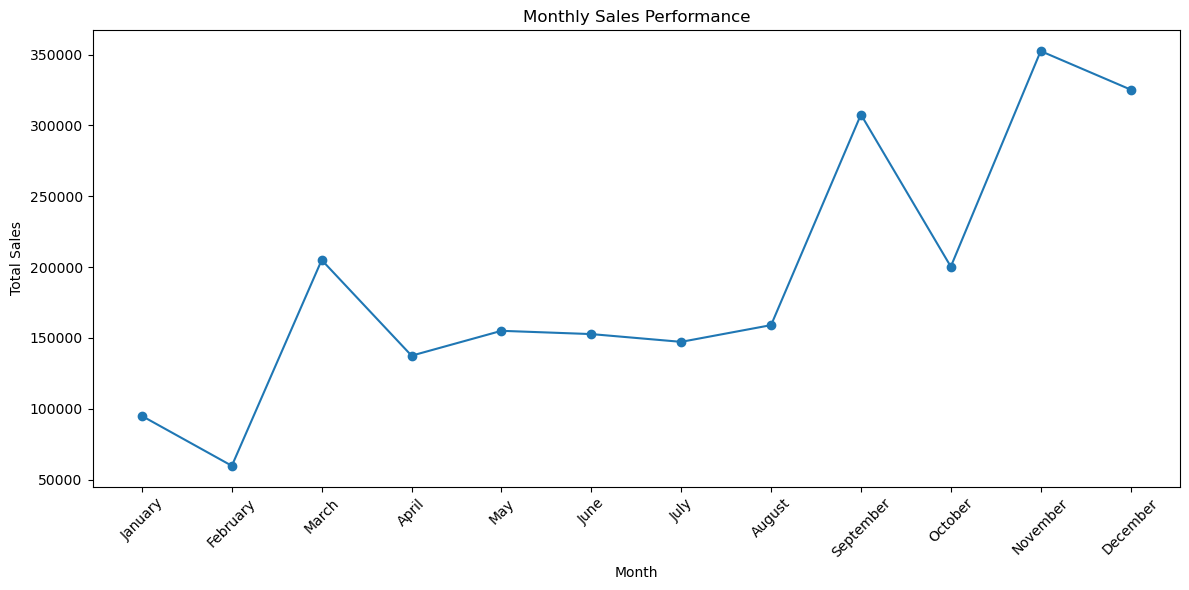

In [126]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance.index,
    monthly_performance['Total_Sales'],
    marker='o'
)

plt.title('Monthly Sales Performance')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\charts\monthly_sales_performance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [127]:
best_month_sales = monthly_performance[
    'Total_Sales'
].max()

lowest_month_sales = monthly_performance[
    'Total_Sales'
].min()

print(
    "Best Sales Month:",
    best_month
)

print(
    "Best Month Sales:",
    round(best_month_sales, 2)
)

print(
    "Lowest Sales Month:",
    lowest_month
)

print(
    "Lowest Month Sales:",
    round(lowest_month_sales, 2)
)

Best Sales Month: November
Best Month Sales: 352461.07
Lowest Sales Month: February
Lowest Month Sales: 59751.25


In [128]:
## Product Performance Analysis

In [129]:
low_performing_products

,Total_Sales,Total_Profit,Quantity_Sold
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624,-4.4660,2
Avery 5,5.760,2.8224,2
Xerox 20,6.480,3.1104,1
Grip Seal Envelopes,7.072,2.3868,2
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700,3.1570,2
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800,3.0420,4
Xerox 1989,7.968,2.6892,2
4009 Highlighters,8.040,2.7336,6
Stockwell Gold Paper Clips,8.096,3.4040,5


In [130]:
loss_making_products = (
    product_performance[
        product_performance['Total_Profit'] < 0
    ]
    .sort_values(
        'Total_Profit'
    )
)

loss_making_products.head(10)

,Total_Sales,Total_Profit,Quantity_Sold
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


In [131]:
## Discount and Profitability Analysis

In [132]:
discount_profit

,Total_Sales,Total_Profit,Average_Profit_Margin
Discount,,,
0.00,1.087908e+06,320987.6032,34.016048
0.10,5.436935e+04,9029.1770,15.579196
0.15,2.755852e+04,1418.9915,3.416290
0.20,7.645944e+05,90337.3060,17.683894
0.30,1.029453e+05,-10357.2186,-11.580278
0.32,1.449346e+04,-2391.1377,-17.429194
0.40,1.164178e+05,-23057.0504,-22.249191
0.45,5.484974e+03,-2493.1111,-45.454545
0.50,5.891854e+04,-20506.4281,-54.909091


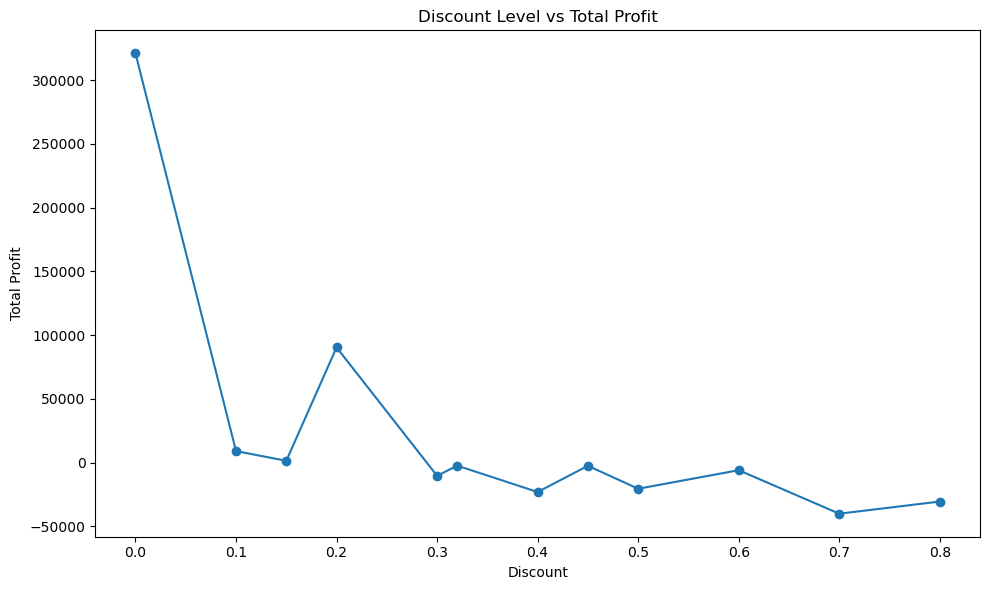

In [133]:
plt.figure(figsize=(10, 6))

plt.plot(
    discount_profit.index,
    discount_profit['Total_Profit'],
    marker='o'
)

plt.title('Discount Level vs Total Profit')
plt.xlabel('Discount')
plt.ylabel('Total Profit')

plt.tight_layout()

plt.savefig(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\charts\discount_vs_profit.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [134]:
## Key Business Findings

In [135]:
repeat_customer_percentage

np.float64(98.48675914249685)

In [136]:
best_month

'November'

In [137]:
lowest_month

'February'

In [138]:
loss_making_products.head(10)

,Total_Sales,Total_Profit,Quantity_Sold
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


In [139]:
discount_profit

,Total_Sales,Total_Profit,Average_Profit_Margin
Discount,,,
0.00,1.087908e+06,320987.6032,34.016048
0.10,5.436935e+04,9029.1770,15.579196
0.15,2.755852e+04,1418.9915,3.416290
0.20,7.645944e+05,90337.3060,17.683894
0.30,1.029453e+05,-10357.2186,-11.580278
0.32,1.449346e+04,-2391.1377,-17.429194
0.40,1.164178e+05,-23057.0504,-22.249191
0.45,5.484974e+03,-2493.1111,-45.454545
0.50,5.891854e+04,-20506.4281,-54.909091


In [140]:
low_performing_products

,Total_Sales,Total_Profit,Quantity_Sold
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624,-4.4660,2
Avery 5,5.760,2.8224,2
Xerox 20,6.480,3.1104,1
Grip Seal Envelopes,7.072,2.3868,2
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700,3.1570,2
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800,3.0420,4
Xerox 1989,7.968,2.6892,2
4009 Highlighters,8.040,2.7336,6
Stockwell Gold Paper Clips,8.096,3.4040,5


In [141]:
loss_making_products = (
    product_performance[
        product_performance['Total_Profit'] < 0
    ]
    .sort_values(
        'Total_Profit'
    )
)

loss_making_products.head(10)

,Total_Sales,Total_Profit,Quantity_Sold
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


In [142]:
low_performing_products

,Total_Sales,Total_Profit,Quantity_Sold
Product Name,,,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624,-4.4660,2
Avery 5,5.760,2.8224,2
Xerox 20,6.480,3.1104,1
Grip Seal Envelopes,7.072,2.3868,2
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700,3.1570,2
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800,3.0420,4
Xerox 1989,7.968,2.6892,2
4009 Highlighters,8.040,2.7336,6
Stockwell Gold Paper Clips,8.096,3.4040,5


In [143]:
loss_making_products.head(10)

,Total_Sales,Total_Profit,Quantity_Sold
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


In [148]:
## Business Recommendations

##Based on the analysis, the following recommendations are proposed:

### 1. Protect High-Value Customers
#The High Value customer segment consists of customers with significantly higher purchase values and average order values. The business should introduce VIP loyalty programs, personalized offers, and exclusive benefits to retain these customers.

### 2. Convert Occasional Customers into Regular Customers
#Occasional customers represent the largest customer segment. The business should use targeted marketing campaigns, personalized product recommendations, loyalty rewards, and promotional offers to encourage these customers to make repeat purchases.

### 3. Improve Furniture Category Profitability
#Furniture generates substantial sales but has a relatively low average profit margin compared with Technology and Office Supplies. The business should review pricing strategies, discount levels, product costs, and supplier costs to improve profitability.

### 4. Strengthen Performance in the South Region
#The South region has the lowest sales among all regions. The business should investigate regional customer preferences, product demand, marketing effectiveness, and pricing strategies to identify opportunities for growth.

### 5. Prepare for November Sales Demand
#November is the strongest sales month in the dataset. The business should plan inventory, marketing campaigns, staffing, and logistics in advance to maximize sales during this period.

### 6. Improve February Sales Performance
#February has the lowest sales performance.## The business could introduce targeted promotions, product bundles, loyalty campaigns, and customer engagement strategies to increase demand during this period.

### 7. Increase Average Order Value
#The business should encourage customers to purchase higher-value products through product bundling, cross-selling, and personalized recommendations.

In [152]:
## Growth Opportunities

#The analysis identifies several opportunities for future business growth:

#- **Customer Conversion:** Convert Occasional customers into Regular customers through targeted retention campaigns.
#- **Customer Upselling:** Increase the Average Order Value of Regular customers through cross-selling and product bundling.
#- **VIP Customer Retention:** Develop loyalty programs for High Value customers to protect long-term revenue.
#- **Regional Expansion:** Focus on improving sales performance in the South region.
#- **Profitability Optimization:** Review pricing and discount strategies, particularly in the Furniture category.
#- **Seasonal Planning:** Use historical sales patterns to prepare for high-demand periods such as November.
#- **Low-Demand Period Activation:** Introduce targeted promotions and campaigns during February to improve sales.
#- **Data-Driven Marketing:** Use customer segmentation to personalize marketing campaigns and improve customer engagement.

In [153]:
##  Conclusion

#The SalesPulse analysis provides a comprehensive view of retail sales performance, customer purchasing behavior, product performance, and regional trends. The business generated strong overall sales and profitability, with Technology emerging as the strongest-performing product category and the West region recording the highest sales performance.

#Customer segmentation using K-Means identified three customer groups: High Value, Regular, and Occasional customers. These segments provide opportunities for targeted customer retention and marketing strategies.

#The analysis also identified areas requiring attention, including the low profitability of the Furniture category, lower sales performance in the South region, and weaker sales during February. By focusing on customer retention, profitability optimization, regional growth, and seasonal planning, the business can improve revenue and long-term performance.

#The findings demonstrate how data analytics can support informed business decision-making and help organizations identify opportunities for sustainable growth.

In [155]:
# Business Performance Dashboard

In [156]:
## SalesPulse – Retail Sales Performance Dashboard

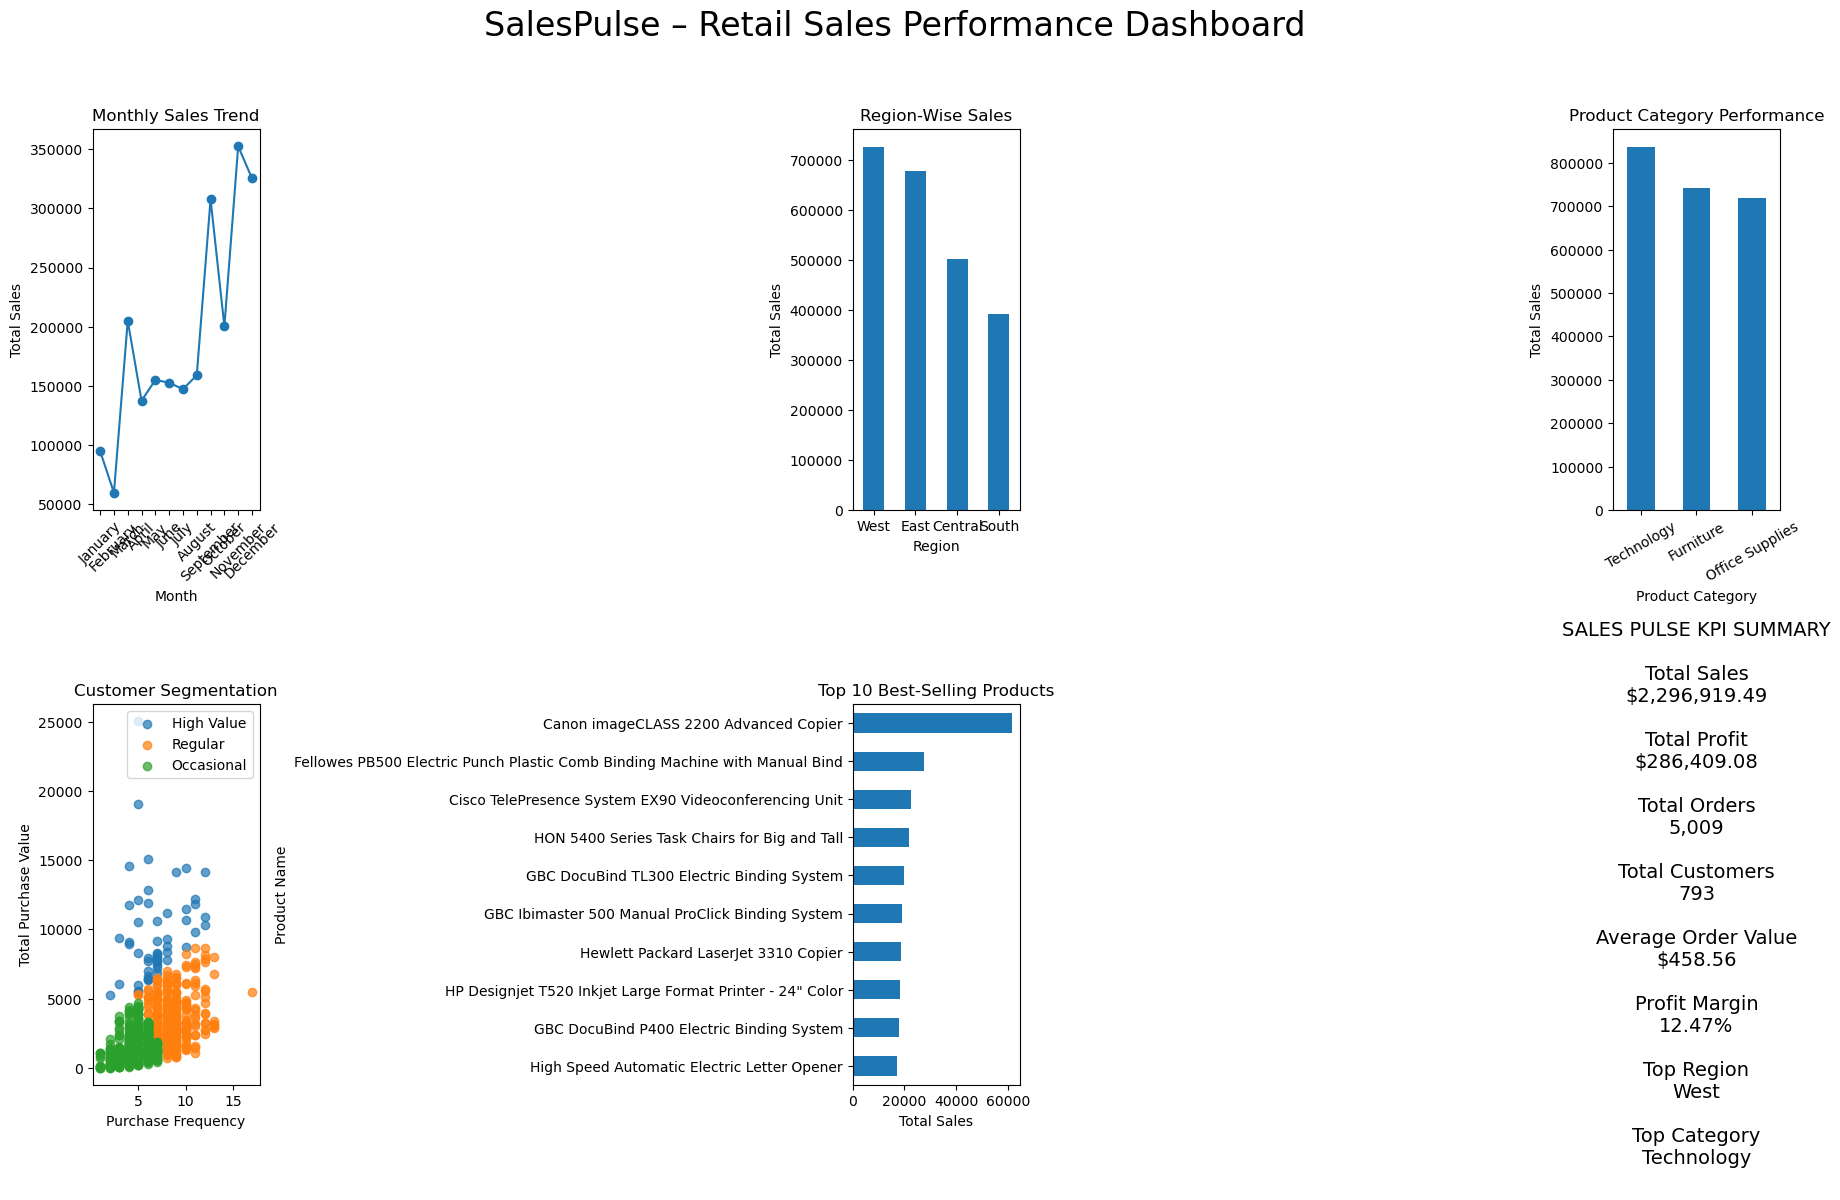

In [159]:
fig = plt.figure(figsize=(18, 12))


# 1. Monthly Sales Trend


ax1 = plt.subplot(2, 3, 1)

ax1.plot(
    monthly_performance.index,
    monthly_performance['Total_Sales'],
    marker='o'
)

ax1.set_title('Monthly Sales Trend')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Sales')

ax1.tick_params(axis='x', rotation=45)



# 2. Region-wise Sales


ax2 = plt.subplot(2, 3, 2)

region_performance['Total_Sales'].plot(
    kind='bar',
    ax=ax2
)

ax2.set_title('Region-Wise Sales')
ax2.set_xlabel('Region')
ax2.set_ylabel('Total Sales')

ax2.tick_params(axis='x', rotation=0)



# 3. Product Category Performance


ax3 = plt.subplot(2, 3, 3)

category_performance['Total_Sales'].plot(
    kind='bar',
    ax=ax3
)

ax3.set_title('Product Category Performance')
ax3.set_xlabel('Product Category')
ax3.set_ylabel('Total Sales')

ax3.tick_params(axis='x', rotation=30)



# 4. Customer Segmentation


ax4 = plt.subplot(2, 3, 4)

for segment in customer_aov['Customer Segment'].unique():

    segment_data = customer_aov[
        customer_aov['Customer Segment'] == segment
    ]

    ax4.scatter(
        segment_data['Purchase_Frequency'],
        segment_data['Total_Purchase_Value'],
        label=segment,
        alpha=0.7
    )

ax4.set_title('Customer Segmentation')
ax4.set_xlabel('Purchase Frequency')
ax4.set_ylabel('Total Purchase Value')

ax4.legend()



# 5. Top 10 Products


ax5 = plt.subplot(2, 3, 5)

top_10_products.sort_values().plot(
    kind='barh',
    ax=ax5
)

ax5.set_title('Top 10 Best-Selling Products')
ax5.set_xlabel('Total Sales')
ax5.set_ylabel('Product Name')



# 6. KPI Summary


ax6 = plt.subplot(2, 3, 6)

ax6.axis('off')

kpi_text = f"""
SALES PULSE KPI SUMMARY

Total Sales
${total_sales:,.2f}

Total Profit
${total_profit:,.2f}

Total Orders
{total_orders:,}

Total Customers
{total_customers:,}

Average Order Value
${average_order_value:,.2f}

Profit Margin
{overall_profit_margin:.2f}%

Top Region
{best_region}

Top Category
{best_selling_category}
"""

ax6.text(
    0.5,
    0.5,
    kpi_text,
    ha='center',
    va='center',
    fontsize=14
)



# Dashboard Title


fig.suptitle(
    'SalesPulse – Retail Sales Performance Dashboard',
    fontsize=24
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)



# Save Dashboard


plt.savefig(
    r"C:\Users\farha\OneDrive\Documents\Desktop\SalesPulse_Project\dashboard\SalesPulse_Dashboard.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()